# Deletion Experiments
Delete-feature ablation chart and deletion NonODs line charts.

In [11]:
from chart_utils import *
from matplotlib.lines import Line2D

## Delete Features (Static) – Relative Runtime

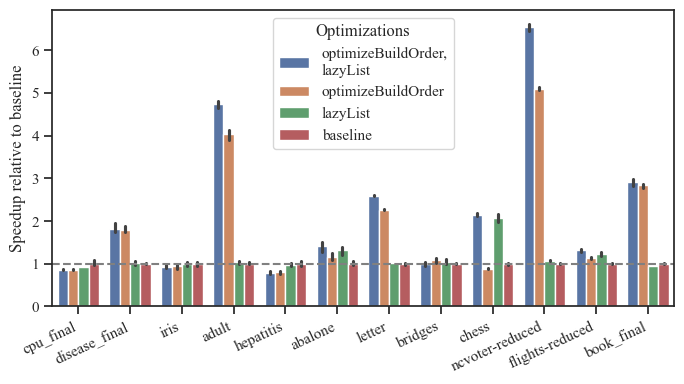

In [12]:
delete_static_df = read_benchmark_metrics(
    str(benchmark_data_path / "dynsbod_results/delete_features_static/benchmark_metrics.json")
)
delete_dyn_df = read_benchmark_metrics(
    str(benchmark_data_path / "dynsbod_results/delete_features_dynamic/benchmark_metrics.json")
)

delete_features_df = delete_static_df
delete_features_df = delete_features_df[~delete_features_df["algo_version"].isin(["8","9"])]


def build_delete_static_config_map():
    configs = []
    for optimize_build_order in [True, False]:
        for use_lazy_list in [True, False]:
            for deletion_mode in ["deleteonly", "afterinsert"]:
                configs.append({
                    "optimizeBuildOrder": optimize_build_order,
                    "useLazyList": use_lazy_list,
                    "deletionMode/efficientUpdates": deletion_mode,
                })
    configs.append({
        "optimizeBuildOrder": True,
        "useLazyList": True,
        "deletionMode/efficientUpdates": "afterinsert",
        "withoutInsertionByRevalidation": True,
    })
    return {str(i): cfg for i, cfg in enumerate(configs)}


delete_static_config_map = build_delete_static_config_map()


def format_config_name(row):
    features = []
    if row['optimizeBuildOrder']:
        features += ['optimizeBuildOrder']
    if row['useLazyList']:
        features += ['lazyList']
    if len(features) == 0:
        features += ['baseline']
    return ',\n'.join(features)


# ── Aggregated data used only for baseline computation ───────────────────────
delete_static_agg = (
    delete_features_df
    .groupby(["dataset", "algo_version"], as_index=False)["deletion_time_ms"]
    .mean()
    .copy()
)

delete_static_agg["optimizeBuildOrder"] = delete_static_agg["algo_version"].map(
    lambda v: delete_static_config_map[v]["optimizeBuildOrder"]
)
delete_static_agg["useLazyList"] = delete_static_agg["algo_version"].map(
    lambda v: delete_static_config_map[v]["useLazyList"]
)
delete_static_agg["deletionMode/efficientUpdates"] = delete_static_agg["algo_version"].map(
    lambda v: delete_static_config_map[v]["deletionMode/efficientUpdates"]
)
delete_static_agg["Optimizations"] = delete_static_agg.apply(format_config_name, axis=1)
delete_static_agg = delete_static_agg.dropna(subset=["deletion_time_ms"])

baseline_static = (
    delete_static_agg[
        (delete_static_agg["optimizeBuildOrder"] == False)
        & (delete_static_agg["useLazyList"] == False)
        & (delete_static_agg["algo_version"].apply(
            lambda v: 'withoutInsertionByRevalidation' not in delete_static_config_map[v]
        ))
    ]
    .groupby("dataset")["deletion_time_ms"]
    .mean()
)

# ── Unaggregated data for barplot (seaborn computes error bars) ───────────────
delete_static_raw = delete_features_df.copy()
delete_static_raw["optimizeBuildOrder"] = delete_static_raw["algo_version"].map(
    lambda v: delete_static_config_map[v]["optimizeBuildOrder"]
)
delete_static_raw["useLazyList"] = delete_static_raw["algo_version"].map(
    lambda v: delete_static_config_map[v]["useLazyList"]
)
delete_static_raw["deletionMode/efficientUpdates"] = delete_static_raw["algo_version"].map(
    lambda v: delete_static_config_map[v]["deletionMode/efficientUpdates"]
)
delete_static_raw["Optimizations"] = delete_static_raw.apply(format_config_name, axis=1)
delete_static_raw = delete_static_raw.dropna(subset=["deletion_time_ms"])
delete_static_raw = delete_static_raw[delete_static_raw["dataset"].isin(baseline_static.index)].copy()
delete_static_raw["relative_runtime"] = delete_static_raw.apply(
    lambda row: baseline_static[row["dataset"]] / row["deletion_time_ms"], axis=1
)
delete_static_raw["dataset_formatted"] = delete_static_raw["dataset"].apply(format_dataset_name)
delete_static_raw = delete_static_raw[delete_static_raw["dataset_formatted"] != "ncvoter"]

plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=delete_static_raw,
    x="dataset_formatted", y="relative_runtime", hue="Optimizations"
)
ax.set_xlabel("")
ax.set_ylabel("Speedup relative to baseline")
plt.xticks(rotation=25, ha="right")
sns.move_legend(ax, "upper center", ncols=1)

plt.tight_layout()
ax.axhline(y=1, color='gray', linestyle='--', linewidth=1.5,
           label='Static algorithm time per insertion')

save_figure("delete_features_static_relative")
plt.show()


## Deletion NonODs Graphs

# Deletion Experiments
This notebook generates performance charts for deletion experiments.

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import re
from collections import defaultdict
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

# Import our utility functions
from chart_utils import *

# Configure plotting style
sns.set_theme(style="ticks", font="serif")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Bitstream Vera Serif', 'Computer Modern Roman']

## Plot Function

In [14]:
def plot_deletion_nonods(deleteonly_files, afterinsert_files=None, ax1=None, plot_idx=None, dataset_name=None):
    """
    Create a chart showing deletion phase with NonODs and ODs.
    
    Parameters:
    - deleteonly_files: List of Path objects for deletion-only intermediate CSV (algo0)
    - afterinsert_files: Unused, kept for API compatibility
    - ax1: Matplotlib axes to plot on (creates new figure if None)
    - plot_idx: Index of the subplot in the grid (for labeling purposes)
    - dataset_name: Optional dataset name for title
    
    Returns:
    - (ax1, ax2): Tuple of primary and secondary axes
    """
    if not deleteonly_files:
        return None, None
    
    if dataset_name is None:
        dataset_name = "Unknown"
    
    # Create figure if no axes provided
    if ax1 is None:
        fig, ax1 = plt.subplots(figsize=(12, 6))
    
    ax2 = ax1.twinx()
    
    # Load deleteonly data (algo0)
    deleteonly_df = get_first_run(load_intermediate_runs(deleteonly_files))
    if not deleteonly_df.empty:
        deleteonly_df['totalNonODs'] = deleteonly_df['currentComptibleNonOds'] + deleteonly_df['currentConstantNonOds']
        deleteonly_df['totalODs'] = deleteonly_df['currentComptibleOds'] + deleteonly_df['currentConstantOds']
        
        # Plot delete-only time on left axis
        sns.lineplot(
            data=deleteonly_df,
            x='lastOperationId',
            y='timePerOperation',
            ax=ax1,
            color='tab:blue',
            linewidth=1.5,
            label='Delete-only time',
            errorbar='sd',
            legend=False
        )
        
        # Plot NonODs and ODs on right axis
        sns.lineplot(
            data=deleteonly_df,
            x='lastOperationId',
            y='totalNonODs',
            ax=ax2,
            color='tab:orange',
            linewidth=1.5,
            label='NonODs',
            errorbar='sd',
            legend=False
        )
        
        sns.lineplot(
            data=deleteonly_df,
            x='lastOperationId',
            y='totalODs',
            ax=ax2,
            color='tab:green',
            linewidth=1.5,
            label='ODs',
            errorbar='sd',
            legend=False
        )
    
    ax1.set_xlabel('')  # Will use shared label
    ax1.set_ylabel('')  # Will use shared label
    ax1.tick_params(axis='y', labelcolor='tab:blue', labelsize=12)
    ax1.tick_params(axis='x', labelsize=12)
    
    # Apply human-readable formatters
    ax1.xaxis.set_major_formatter(FuncFormatter(human_format))
    ax1.yaxis.set_major_formatter(FuncFormatter(human_format))
    
    ax2.set_ylabel('')  # Will use shared label
    ax2.tick_params(axis='y', labelsize=12)
    ax2.yaxis.set_major_formatter(FuncFormatter(human_format))
    
    # Title sits tightly inside the subplot frame
    ax1.set_title(format_dataset_name(dataset_name, plot_idx), fontsize=12, pad=4, y=1.01)
    
    return ax1, ax2


## Generate Deletion Performance Graphs

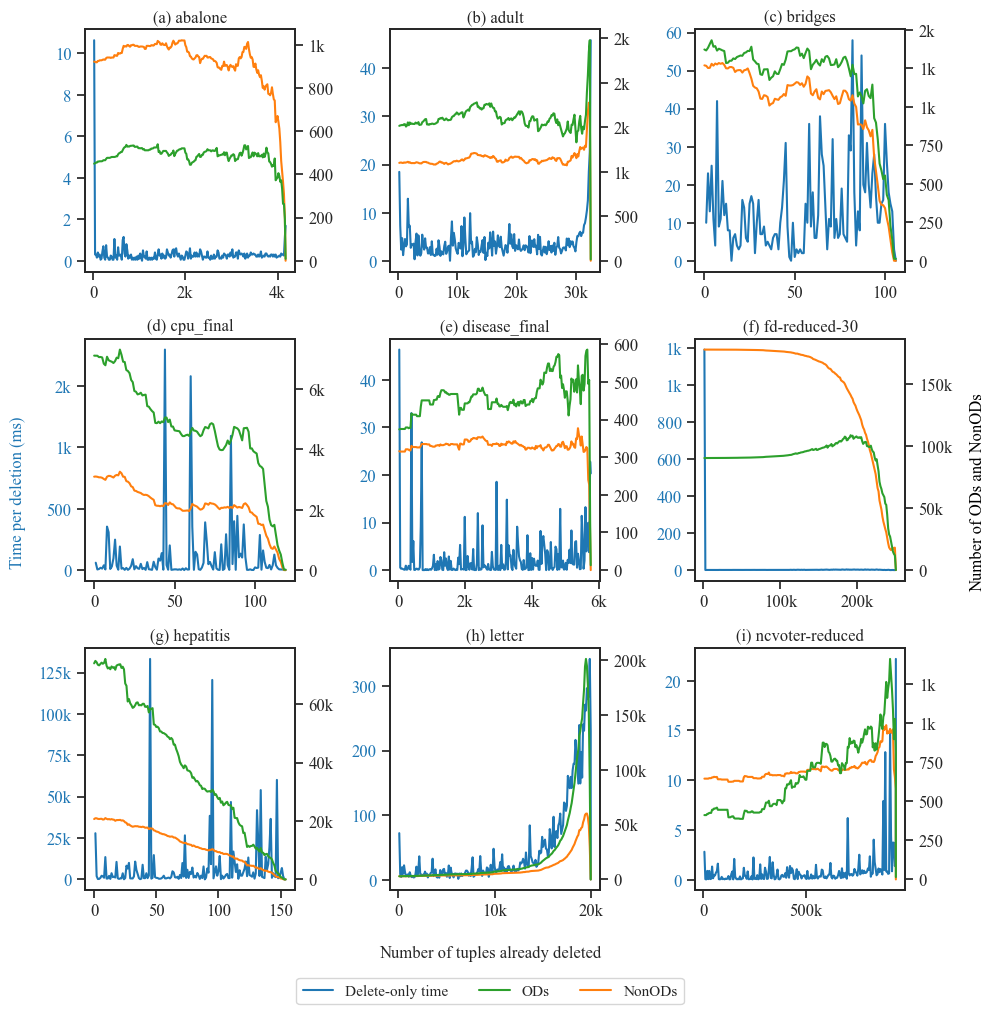

In [17]:
# Get all deletion experiment files from intermediate_delete only.
# NOTE: intermediate_dynamic contains insertion/update scenarios (events_with_updates),
# NOT deletion experiments - those files show 0 NonODs because all ODs hold after insertion.
all_deleteonly_files = list(
    (benchmark_data_path / 'dynsbod_results/intermediate_delete/').glob('algo0_java0_*_stdout.intermediate.csv_delete.csv')
)

# Group by dataset
delete_dataset_files = defaultdict(lambda: defaultdict(list))

# Process deleteonly files (algo0)
for file in all_deleteonly_files:
    match = re.search(r'algo0_java0_(.+?)_run\d+_stdout\.intermediate\.csv_delete\.csv$', file.name)
    if match:
        dataset_name = match.group(1)
        delete_dataset_files[dataset_name]['deleteonly'].append(file)

# Create grid of subplots for deletion NonODs
datasets_with_deletion = [
    d for d in sorted(delete_dataset_files.keys())
    if 'deleteonly' in delete_dataset_files[d]
    and d not in ['chess', 'iris']
]

n_datasets = len(datasets_with_deletion)
n_cols = 3
n_rows = (n_datasets + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 10))
fig.subplots_adjust(hspace=0.45, wspace=0.45)
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.flatten()

for plot_idx, dataset_name in enumerate(datasets_with_deletion):
    if plot_idx >= len(axes):
        break
    
    plot_deletion_nonods(
        deleteonly_files=delete_dataset_files[dataset_name]['deleteonly'],
        ax1=axes[plot_idx],
        plot_idx=plot_idx,
        dataset_name=dataset_name
    )

# Hide unused subplots
for idx in range(len(datasets_with_deletion), len(axes)):
    axes[idx].set_visible(False)

# Create shared legend
if len(datasets_with_deletion) > 0:
    legend_elements = [
        Line2D([0], [0], color='tab:blue', linewidth=1.5, label='Delete-only time'),
        Line2D([0], [0], color='tab:green', linewidth=1.5, label='ODs'),
        Line2D([0], [0], color='tab:orange', linewidth=1.5, label='NonODs'),
    ]
    
    fig.legend(handles=legend_elements, loc='lower center', ncol=3,
               bbox_to_anchor=(0.5, -0.02), fontsize=11)

# Add shared axes labels
fig.supxlabel('Number of tuples already deleted', fontsize=12, y=0.03)

fig.text(0.02, 0.5, 'Time per deletion (ms)', va='center', rotation='vertical',
         fontsize=12, color='tab:blue')

fig.text(0.98, 0.5, 'Number of ODs and NonODs', va='center', rotation='vertical',
         fontsize=12, color='black')

plt.tight_layout(rect=[0.03, 0.02, 0.98, 1])
save_figure("deletion_nonods")
plt.show()
